# GrainTrace - Experiment

## 1. Purpose

This notebook is dedicated to training embedding models for bow matching using

- Model: Dinov2
- Training Method: Siamese
- Loss:
  - loss 1: Cosine Similarity
  - loss 2: Triplet Loss
- Objective
  - Same bows images give similar embeddings
  - Different bow images gives separated embeddings

## 2. Imports

In [ ]:
import os
from PIL import Image

import torch
import torch.nn.functional as F

from torchvision import transforms

import numpy as np

from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import random
import torch.nn as nn
from sklearn.model_selection import train_test_split
import zipfile
from collections import defaultdict

from sklearn.metrics import silhouette_score


## 3. Configuration

In [ ]:
CONFIG = {
    "IMAGE_SIZE": 224,
    "BATCH_SIZE": 16,

    "EMBEDDING_DIM": 128,

    "DEVICE": "cuda"
}

## 4. Dataset Loading

In [ ]:
zip_path = "/content/transformed_bows.zip"

extract_folder = "/content/my_finetuning"

os.makedirs(extract_folder, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

dataset_path = "/content/my_finetuning"

print("Files extracted successfully!")

Files extracted successfully!


## 5. Sample Visualization

In [ ]:
# SAMPLE VIS CODE

## 6. Preprocessing & Data Augmentation

In [ ]:
# Pre processing & Data Augmentation
transform_resize = transforms.Resize((224, 224))
transform_normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
transform_grayscale=  transforms.Grayscale(num_output_channels=3)
transfom_RandomHorizontalFlip = transforms.RandomHorizontalFlip()
transform_color_jitter = transforms.ColorJitter(0.3, 0.3, 0.3)

transform_1 = transforms.Compose([
    transform_grayscale,
    transform_resize,
    transforms.ToTensor(),
    transform_normalize
])

transform_2 = transforms.Compose([
    transform_resize,
    # transform_grayscale,
    transforms.RandomGrayscale(p=0.2),
    transfom_RandomHorizontalFlip,
    transform_color_jitter,
    transforms.ToTensor(),
    transform_normalize
])

val_transform = transforms.Compose([
    transform_resize,
    transforms.ToTensor(),
    transform_normalize
])


## 7. Dataset creation

### 7.1 Dataset class

In [ ]:

def datasetcreationhelper(dataset_path):

    grouped_images = defaultdict(list)

    for bow_folder in os.listdir(dataset_path):

        bow_path = os.path.join(dataset_path, bow_folder)

        if not os.path.isdir(bow_path):
            continue

        for image_name in os.listdir(bow_path):

            image_path = os.path.join(bow_path, image_name)

            grouped_images[bow_folder].append(image_path)

    return grouped_images

In [ ]:
# Dataset class
class CosineSimilarityBowDataset(Dataset):

    def __init__(self, bow_dict, transform=None):

        self.bow_dict = bow_dict

        self.bow_ids = list(bow_dict.keys())

        self.transform = transform

    def __len__(self):

        return len(self.bow_ids)

    def load_image(self, image_path):

        image = Image.open(image_path)

        return image

    def __getitem__(self, idx):

        anchor_id = self.bow_ids[idx]

        same_bow_images = self.bow_dict[anchor_id]

        img1_path, img2_path = random.sample(same_bow_images, 2)

        img1 = self.load_image(img1_path)
        img2 = self.load_image(img2_path)

        img1 = self.transform(img1)
        img2 = self.transform(img2)

        positive_label = torch.tensor(1.0, dtype=torch.float32)

        negative_id = random.choice(self.bow_ids)

        while negative_id == anchor_id:

            negative_id = random.choice(self.bow_ids)

        negative_path = random.choice(self.bow_dict[negative_id])

        negative_img = self.load_image(negative_path)

        negative_img = self.transform(negative_img)

        negative_label = torch.tensor(0.0, dtype=torch.float32)

        return (img1, img2, positive_label, img1, negative_img, negative_label)


In [ ]:
class CosineSimilarityBowDataset(Dataset):

    def __init__(self, bow_dict, transform=None):

        self.bow_dict = bow_dict

        self.bow_ids = list(bow_dict.keys())

        self.transform = transform

    def __len__(self):

        return len(self.bow_ids)

    def load_image(self, image_path):

        image = Image.open(image_path)

        return image

    def __getitem__(self, idx):

        anchor_id = self.bow_ids[idx]
        same_images = self.bow_dict[anchor_id]

        is_positive = random.random() < 0.5

        img1_path = random.choice(same_images)
        img1 = self.transform(self.load_image(img1_path))

        if is_positive:
            img2_path = random.choice(same_images)
            while img2_path == img1_path and len(same_images) > 1:
                img2_path = random.choice(same_images)
            label = torch.tensor(1.0, dtype=torch.float32)
        else:
            negative_id = random.choice(self.bow_ids)
            while negative_id == anchor_id:
                negative_id = random.choice(self.bow_ids)

            img2_path = random.choice(self.bow_dict[negative_id])
            label = torch.tensor(0.0, dtype=torch.float32)
        img2 = self.transform(self.load_image(img2_path))

        return img1, img2, label



In [ ]:
class TripletLossBowDataset(Dataset):
    def __init__(self, bow_dict, transform=None):
        self.bow_dict = bow_dict
        self.bow_ids = list(bow_dict.keys())
        self.transform = transform
        self.all_samples = []
        for label, paths in bow_dict.items():
            for path in paths:
                self.all_samples.append((path, label))

    def __len__(self):
        return len(self.all_samples)

    def __getitem__(self, idx):
        img_path, label_name = self.all_samples[idx]
        image = Image.open(img_path)
        if self.transform:
            image = self.transform(image)
        label_idx = self.bow_ids.index(label_name)
        return image, label_idx


### 7.2 Datalaoder

In [ ]:
# Dataset loaders
bow_dict= datasetcreationhelper(dataset_path)
bow_ids = list(bow_dict.keys())

train_ids, val_ids = train_test_split(bow_ids, test_size=0.2, random_state=42)

train_bow_dict = {k: bow_dict[k] for k in train_ids}

val_bow_dict = {k: bow_dict[k] for k in val_ids}

print(len(train_bow_dict))
print(len(val_bow_dict))

train_dataset_CoSim = CosineSimilarityBowDataset(train_bow_dict, transform=transform_1)
val_dataset_CoSim = CosineSimilarityBowDataset(val_bow_dict, transform=val_transform)

train_dataset_Triplet = TripletLossBowDataset(train_bow_dict, transform=transform_2)
val_dataset_Triplet = TripletLossBowDataset(val_bow_dict, transform=val_transform)

train_loader_Triplet = DataLoader(train_dataset_Triplet, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)
val_loader_Triplet = DataLoader(val_dataset_Triplet, batch_size=CONFIG["BATCH_SIZE"], shuffle=False)

train_loader_CoSim = DataLoader(train_dataset_CoSim, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)

val_loader_CoSim = DataLoader(val_dataset_CoSim, batch_size=CONFIG["BATCH_SIZE"], shuffle=False)

20
6


## 8. Models

### 8.1 Dinov2

Pretrained Dinov2

In [ ]:
class DinoV2Model(nn.Module):
  def __init__(self):
    super().__init__()
    model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
    
    self.backbone = model
  def forward(self, x):
    out = self.backbone(x)
    return out

Dinov2 with linear projection head

In [ ]:
class Dinov2LinearProjectionHead(nn.Module):

    def __init__(self, input_dim=768, projection_dim=256):

        super().__init__()

        self.backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')

        self.projection = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, projection_dim))

    def forward_once(self, x):

        with torch.no_grad():
            features = self.backbone(x)

        embedding = self.projection(features)

        embedding = F.normalize(embedding, p=2, dim=1)

        return embedding

    def forward(self, x1, x2):

        emb1 = self.forward_once(x1)
        emb2 = self.forward_once(x2)

        return emb1, emb2


Dinov2 with projection head (Triplet Loss)

In [ ]:
class Dinov2LinearProjectionHead_TripletLoss(nn.Module):
    def __init__(self, projection_dim=256):
        super().__init__()
        self.backbone =  torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
        self.head = nn.Sequential(
            nn.Linear(768, 512),
            nn.GELU(),
            nn.Linear(512, projection_dim, bias=False)
        )

    def forward(self, x):
        with torch.no_grad():
            features = self.backbone.forward_features(x)
            patch_tokens = features["x_norm_patchtokens"]
            pooled = patch_tokens.mean(dim=1)

        embedding = self.head(pooled)
        return F.normalize(embedding, p=2, dim=1)


## 9. Model Experiments

### 9.1 Dinov2 ineference without finetuning

In [ ]:
model = DinoV2Model()
model = model.to(CONFIG['DEVICE'])

model.eval()

embeddings_nofinetuning = []
labels_nofinetuning = []

dataset= datasetcreationhelper(dataset_path)
for bow_folder, image_paths in dataset.items():
   for image_path in image_paths:
        image = Image.open(image_path)

        image_tensor = transform_1(image).unsqueeze(0).to(CONFIG['DEVICE'])

        with torch.no_grad():

            embedding = model(image_tensor)

            embedding = F.normalize(embedding, p=2, dim=1)

        embedding = embedding.squeeze().cpu().numpy()

        embeddings_nofinetuning.append(embedding)

        labels_nofinetuning.append(bow_folder)

embeddings_nofinetuning = np.array(embeddings_nofinetuning)
labels_nofinetuning = np.array(labels_nofinetuning)





Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 226MB/s]


9.2 Dinov2 with cosine similarity finetuning

In [ ]:
model_cosim = Dinov2LinearProjectionHead().to(CONFIG['DEVICE'])

for param in model_cosim.backbone.parameters():
    param.requires_grad = False

LR = 1e-5
Epochs = 10

class CosineContrastiveLoss(nn.Module):

    def __init__(self, margin=0.5):

        super().__init__()

        self.margin = margin

    def forward(self, emb1, emb2, label):

        cosine_sim = F.cosine_similarity(emb1, emb2)

        positive_loss = label * (1 - cosine_sim)

        negative_loss = (1 - label) * torch.clamp(cosine_sim - self.margin, min=0.0)

        loss = (positive_loss + negative_loss).mean()

        return loss

criterion = CosineContrastiveLoss(margin=0.5)

optimizer = torch.optim.Adam(model_cosim.projection.parameters(), lr=LR)

for epoch in range(Epochs):


    model_cosim.train()

    train_loss = 0

    for batch in train_loader_CoSim:

        pos1, pos2, pos_label, neg1, neg2, neg_label = batch

        pos1 = pos1.to(CONFIG['DEVICE'])
        pos2 = pos2.to(CONFIG['DEVICE'])

        neg2 = neg2.to(CONFIG['DEVICE'])

        pos_label = pos_label.to(CONFIG['DEVICE'])
        neg_label = neg_label.to(CONFIG['DEVICE'])

        emb1 = model_cosim.forward_once(pos1)

        emb2 = model_cosim.forward_once(pos2)

        emb3 = model_cosim.forward_once(neg2)

        pos_loss = criterion(emb1, emb2, pos_label)

        neg_loss = criterion(emb1, emb3, neg_label)

        loss = pos_loss + neg_loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = (train_loss / len(train_loader_CoSim))

    model_cosim.eval()

    val_loss = 0

    with torch.no_grad():

        for batch in val_loader_CoSim:

            pos1, pos2, pos_label, neg1, neg2, neg_label = batch

            pos1 = pos1.to(CONFIG['DEVICE'])
            pos2 = pos2.to(CONFIG['DEVICE'])

            neg2 = neg2.to(CONFIG['DEVICE'])

            pos_label = pos_label.to(CONFIG['DEVICE'])
            neg_label = neg_label.to(CONFIG['DEVICE'])

            emb1 = model_cosim.forward_once(pos1)

            emb2 = model_cosim.forward_once(pos2)

            emb3 = model_cosim.forward_once(neg2)

            pos_loss = criterion(emb1, emb2, pos_label)

            neg_loss = criterion(emb1, emb3, neg_label)

            loss = pos_loss + neg_loss

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader_CoSim)

    print(
        f"Epoch {epoch+1}/{Epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )



Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Epoch 1/10 | Train Loss: 0.5084 | Val Loss: 0.4615
Epoch 2/10 | Train Loss: 0.4358 | Val Loss: 0.3799
Epoch 3/10 | Train Loss: 0.4409 | Val Loss: 0.4344
Epoch 4/10 | Train Loss: 0.4316 | Val Loss: 0.4087
Epoch 5/10 | Train Loss: 0.4546 | Val Loss: 0.4164
Epoch 6/10 | Train Loss: 0.4641 | Val Loss: 0.4611
Epoch 7/10 | Train Loss: 0.4444 | Val Loss: 0.4532
Epoch 8/10 | Train Loss: 0.4238 | Val Loss: 0.4204
Epoch 9/10 | Train Loss: 0.4247 | Val Loss: 0.4390
Epoch 10/10 | Train Loss: 0.4696 | Val Loss: 0.4308


9.2 Dinov2 with Triplet Loss finetuning

In [ ]:
LR = 5e-5
MARGIN = 0.6
EPOCHS = 50

model_tripletloss = Dinov2LinearProjectionHead_TripletLoss().to(CONFIG['DEVICE'])
for param in model_tripletloss.backbone.parameters():
    param.requires_grad = False

optimizer = torch.optim.AdamW(model_tripletloss.head.parameters(), lr=LR, weight_decay=1e-4)


def batch_hard_triplet_loss(embeddings, labels, margin=0.6):

    dist_matrix = 1 - torch.mm(embeddings, embeddings.t())

    mask_pos = labels.unsqueeze(0) == labels.unsqueeze(1)
    mask_neg = ~mask_pos


    hard_pos = (dist_matrix * mask_pos.float()).max(dim=1)[0]


    dist_matrix_neg = dist_matrix.clone()
    dist_matrix_neg[mask_pos] = float('inf')
    hard_neg = dist_matrix_neg.min(dim=1)[0]

    loss = F.relu(hard_pos - hard_neg + margin).mean()
    return loss

for epoch in range(EPOCHS):
    model_tripletloss.train()
    total_train_loss = 0

    for imgs, labels in train_loader_Triplet:
        imgs, labels = imgs.to(CONFIG['DEVICE']), labels.to(CONFIG['DEVICE'])

        embs = model_tripletloss(imgs)
        loss = batch_hard_triplet_loss(embs, labels, margin=MARGIN)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()


    model_tripletloss.eval()
    pos_sims, neg_sims = [], []
    with torch.no_grad():
        for imgs, labels in val_loader_Triplet:
            imgs = imgs.to(CONFIG['DEVICE'])
            embs = model_tripletloss(imgs)

            sim_matrix = torch.mm(embs, embs.t())
            lbl_cpu = labels.cpu().numpy()

            for i in range(len(lbl_cpu)):
                for j in range(i + 1, len(lbl_cpu)):
                    if lbl_cpu[i] == lbl_cpu[j]:
                        pos_sims.append(sim_matrix[i, j].item())
                    else:
                        neg_sims.append(sim_matrix[i, j].item())

    print(f"Epoch {epoch+1:02d} | Loss: {total_train_loss/len(train_loader_Triplet):.4f} | "
          f"Pos Sim: {np.mean(pos_sims) if pos_sims else 0:.3f} | "
          f"Neg Sim: {np.mean(neg_sims) if neg_sims else 0:.3f}")


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Epoch 01 | Loss: 0.6118 | Pos Sim: 0.923 | Neg Sim: 0.873
Epoch 02 | Loss: 0.5853 | Pos Sim: 0.930 | Neg Sim: 0.870
Epoch 03 | Loss: 0.5692 | Pos Sim: 0.891 | Neg Sim: 0.781
Epoch 04 | Loss: 0.5224 | Pos Sim: 0.692 | Neg Sim: 0.377
Epoch 05 | Loss: 0.4279 | Pos Sim: 0.560 | Neg Sim: 0.118
Epoch 06 | Loss: 0.3517 | Pos Sim: 0.561 | Neg Sim: 0.104
Epoch 07 | Loss: 0.3334 | Pos Sim: 0.550 | Neg Sim: 0.069
Epoch 08 | Loss: 0.3038 | Pos Sim: 0.552 | Neg Sim: 0.070
Epoch 09 | Loss: 0.2495 | Pos Sim: 0.540 | Neg Sim: -0.025
Epoch 10 | Loss: 0.2837 | Pos Sim: 0.542 | Neg Sim: 0.010
Epoch 11 | Loss: 0.2851 | Pos Sim: 0.543 | Neg Sim: 0.015
Epoch 12 | Loss: 0.3017 | Pos Sim: 0.557 | Neg Sim: -0.005
Epoch 13 | Loss: 0.2792 | Pos Sim: 0.525 | Neg Sim: -0.006
Epoch 14 | Loss: 0.2666 | Pos Sim: 0.548 | Neg Sim: 0.010
Epoch 15 | Loss: 0.3075 | Pos Sim: 0.556 | Neg Sim: -0.013
Epoch 16 | Loss: 0.2458 | Pos Sim: 0.549 | Neg Sim: -0.027
Epoch 17 | Loss: 0.2297 | Pos Sim: 0.559 | Neg Sim: 0.006
Epoch 18 

## 10. Model Evaluation

In [ ]:
def visualiseAndCompare(embeddings, labels):
  print("\n==============================")
  print("COSINE SIMILARITY TEST")
  print("==============================\n")

  num_images = len(embeddings)
  same_scores = []
  different_scores = []

  for i in range(num_images):

      for j in range(i + 1, num_images):

          emb1 = torch.tensor(embeddings[i])
          emb2 = torch.tensor(embeddings[j])

          similarity = F.cosine_similarity(
              emb1.unsqueeze(0),
              emb2.unsqueeze(0)
          ).item()

          same_bow = labels[i] == labels[j]
          if same_bow:
              same_scores.append(similarity)
          else:
              different_scores.append(similarity)

  print("\n==============================")
  print("AVERAGE VALIDATION SCORES")
  print("==============================\n")

  print(
      f"Average SAME bow similarity: "
      f"{np.mean(same_scores):.4f}"
  )

  print(
      f"Average DIFFERENT bow similarity: "
      f"{np.mean(different_scores):.4f}"
  )
  print("\n==============================")
  print("Silhouette Score")
  print("==============================\n")
  score = silhouette_score(
      embeddings,
      labels,
      metric='cosine'
  )

  print("Silhouette Score:", score)


  tsne = TSNE(
      n_components=2,
      perplexity=5,
      random_state=42
  )

  embeddings_2d = tsne.fit_transform(
      embeddings
  )



  plt.figure(figsize=(10, 8))

  unique_labels = list(set(labels))

  colors = plt.cm.tab10(
      np.linspace(0, 1, len(unique_labels))
  )

  label_to_color = {
      label: colors[i]
      for i, label in enumerate(unique_labels)
  }

  for i in range(len(embeddings_2d)):

      x = embeddings_2d[i, 0]
      y = embeddings_2d[i, 1]

      label = labels[i]

      plt.scatter(
          x,
          y,
          color=label_to_color[label],
          s=80
      )

      plt.text(
          x,
          y,
          label,
          fontsize=9
      )

  plt.title("DINOv2 Embeddings t-SNE")

  plt.grid(True)

  plt.show()

Evaluation for Dinov2 with cosine similarity finetuning


COSINE SIMILARITY TEST


AVERAGE VALIDATION SCORES

Average SAME bow similarity: 0.8952
Average DIFFERENT bow similarity: 0.8176

Silhouette Score

Silhouette Score: 0.21731512


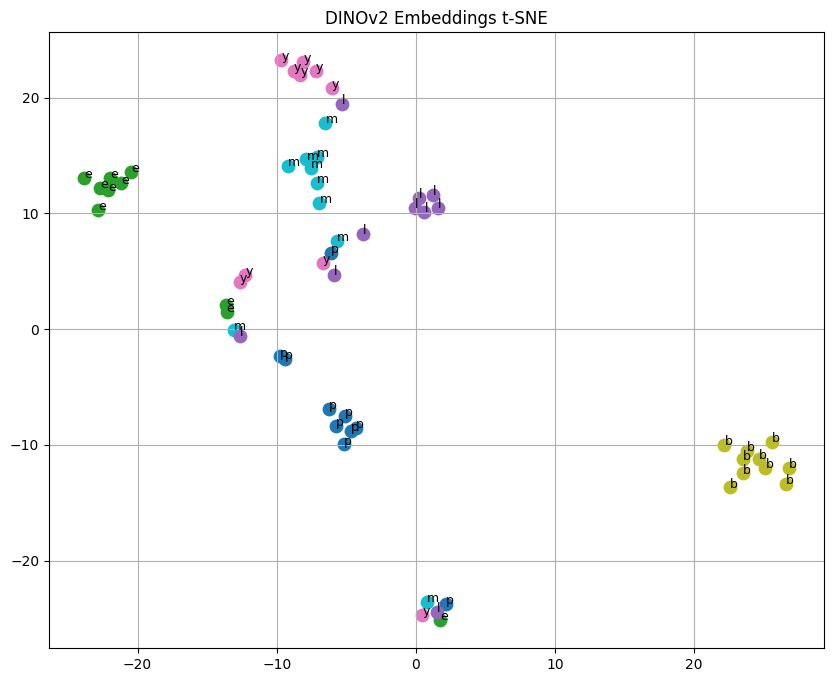

In [ ]:
model_cosim.eval()

val_embeddings = []
val_labels = []
val_image_paths = []

with torch.no_grad():

    for bow_id in val_bow_dict:

        image_paths = val_bow_dict[bow_id]

        for image_path in image_paths:
                image = Image.open(image_path)
                image_tensor = val_transform(image)\
                               .unsqueeze(0)\
                               .to(CONFIG['DEVICE'])

                embedding = model_cosim.forward_once(
                    image_tensor
                )

                embedding = embedding.squeeze()\
                                     .cpu()\
                                     .numpy()

                val_embeddings.append(
                    embedding
                )

                val_labels.append(
                    bow_id
                )

                val_image_paths.append(
                    image_path
                )






val_embeddings = np.array(
    val_embeddings
)

visualiseAndCompare(val_embeddings, val_labels)

Evaluation Dinov2 with Triplet Loss finetuning


COSINE SIMILARITY TEST


AVERAGE VALIDATION SCORES

Average SAME bow similarity: 0.5778
Average DIFFERENT bow similarity: 0.0961

Silhouette Score

Silhouette Score: 0.41803062


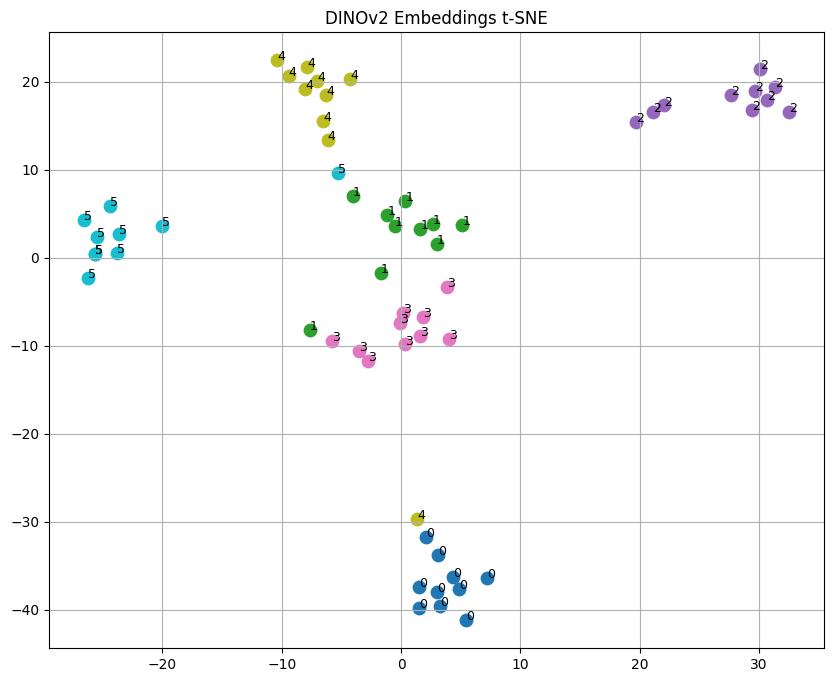

In [ ]:
model_tripletloss.eval()
all_embeddings = []
all_labels = []

with torch.no_grad():
  for i in range(len(val_dataset_Triplet)):
      img, label = val_dataset_Triplet[i]
      img = img.unsqueeze(0).to(CONFIG['DEVICE'])

      # Get the L2-normalized embedding
      emb = model_tripletloss(img).cpu().numpy()

      all_embeddings.append(emb)
      all_labels.append(label)

all_embeddings = np.vstack(all_embeddings)
all_labels = np.array(all_labels)


visualiseAndCompare(all_embeddings, all_labels)

In [ ]:
# loss report

## 11. Embedding Visualization

TSNE and UMAP 2D and 3D

#Further Ideas

In [ ]:
# optimising the triplet loss, Contouring, backbone finetuning